In [ ]:
# Housing price prediction
housing_price_url = "https://raw.githubusercontent.com/ziafaq/genai/refs/heads/main/housing.csv"
import pandas as pd
import numpy as np
housing_df = pd.read_csv(housing_price_url)
housing_df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
housing_df['total_bedrooms'].unique()

array([ 129., 1106.,  190., ..., 3008., 1857., 1052.])

In [ ]:
# fill missing values in total_bedrooms
housing_df['total_bedrooms'].fillna(housing_df['total_bedrooms'].median(), inplace=True)
housing_df

/tmp/ipython-input-383341991.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_df['total_bedrooms'].fillna(housing_df['total_bedrooms'].median(), inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
# Ocean proximity - has category value
housing_df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
housing_df = pd.get_dummies(housing_df, columns=['ocean_proximity'], dtype=int)
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0,1,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = housing_df.drop('median_house_value', axis=1)
y = housing_df['median_house_value']
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,1.267645,-1.367976,0.346478,0.224718,0.214986,0.772251,0.322924,-0.321654,-0.891156,-0.681889,-0.015566,-0.353264,2.601007
8267,0.703627,-0.871699,1.617807,0.342065,0.596500,-0.098440,0.670799,-0.030620,-0.891156,-0.681889,-0.015566,-0.353264,2.601007
17445,-0.454356,-0.455012,-1.957806,-0.338639,-0.490815,-0.450778,-0.427755,0.150349,-0.891156,-0.681889,-0.015566,-0.353264,2.601007
14265,1.227714,-1.377340,0.584852,-0.556832,-0.404974,-0.006602,-0.378059,-1.014947,-0.891156,-0.681889,-0.015566,-0.353264,2.601007
2271,-0.114948,0.537543,1.141059,-0.116322,-0.252369,-0.486983,-0.312669,-0.166583,-0.891156,1.466514,-0.015566,-0.353264,-0.384466
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.803453,-0.867017,0.505394,-0.598545,-0.800795,-0.677723,-0.739013,1.315592,1.122138,-0.681889,-0.015566,-0.353264,-0.384466
11964,1.067992,-0.754652,0.346478,0.205466,0.079072,0.289220,-0.132192,-0.431983,-0.891156,1.466514,-0.015566,-0.353264,-0.384466
5390,0.593818,-0.749970,0.584852,-0.245128,0.076687,0.291870,0.071825,-0.492832,1.122138,-0.681889,-0.015566,-0.353264,-0.384466
860,-1.193070,0.912092,-1.083767,0.430534,0.143452,0.310414,0.155525,0.973025,1.122138,-0.681889,-0.015566,-0.353264,-0.384466


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)


LinearRegression()

In [ ]:

lin_reg_model.score(X_train, y_train)
y_train_pred = lin_reg_model.predict(X_train)
print('MSE: ', mean_squared_error(y_train, y_train_pred))
print('R2: ', r2_score(y_train, y_train_pred))

MSE:  4683203783.504253
R2:  0.6496648627123223


In [ ]:
# defining a function to record results
def record_result(model, params)->pd.DataFrame:
  prediction = model.predict(X_val)
  mse = round(mean_squared_error(y_val, prediction), 2)
  r2 = r2_score(y_val, prediction)
  print('MSE: ', mse)
  print('R2: ', r2)
  results_df=pd.DataFrame(columns=['Model', 'MSE', 'R2', 'Params'])
  results_df.loc[len(results_df)] = {"Model":model, "MSE":mse, "R2": r2, "Params": params}
  return results_df

In [ ]:
result = record_result(lin_reg_model, "Linear regression")
display(result)

MSE:  4908476721.16
R2:  0.6254240620553606


,Model,MSE,R2,Params
0,LinearRegression(),4.908477e+09,0.625424,Linear regression


In [ ]:
from keras import Sequential
from keras.layers import Dense, Input, Dropout
from keras.callbacks import EarlyStopping
housing_model = Sequential()
housing_model.add(Input(shape=(X_train.shape[1],)))
"""
housing_model.add(Dense(256, activation='relu'))
housing_model.add(Dropout(0.5))
housing_model.add(Dense(128, activation='relu'))
housing_model.add(Dropout(0.5))
"""
housing_model.add(Dense(64, activation='relu'))
housing_model.add(Dropout(0.5))
housing_model.add(Dense(32, activation='relu'))
housing_model.add(Dropout(0.5))
"""
housing_model.add(Dense(16, activation='relu'))
housing_model.add(Dropout(0.5))

housing_model.add(Dense(8, activation='relu'))
housing_model.add(Dropout(0.5))
housing_model.add(Dense(4, activation='relu'))
housing_model.add(Dropout(0.5))
housing_model.add(Dense(2, activation='relu'))
housing_model.add(Dropout(0.5))
"""
housing_model.add(Dense(1))
housing_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.metrics import R2Score
from keras.optimizers import Adam
housing_model.compile(optimizer=Adam(learning_rate=0.35), loss='mse', metrics=[R2Score()])

In [ ]:
housing_model_values = housing_model.fit(X_train, y_train,
                                         epochs=100,
                                         batch_size=10000,
                                         validation_data=(X_val,y_val),
                                         verbose=1,
                                         callbacks=[EarlyStopping(monitor="val_loss", patience=10)])

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - loss: 7562924032.0000 - r2_score: 0.4332 - val_loss: 4740536832.0000 - val_r2_score: 0.6382
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 7492619776.0000 - r2_score: 0.4405 - val_loss: 6375543296.0000 - val_r2_score: 0.5135
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 8049699840.0000 - r2_score: 0.3927 - val_loss: 4569891328.0000 - val_r2_score: 0.6513
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 7383046656.0000 - r2_score: 0.4499 - val_loss: 4648571392.0000 - val_r2_score: 0.6453
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 7488505856.0000 - r2_score: 0.4409 - val_loss: 4853916160.0000 - val_r2_score: 0.6296
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 7287858688.0000 - r2_score: 0.4542 - val_loss: 5245640704.0000 - val_r2_score: 0.5997
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 7257986560.0000 - r2_score: 0.4566 - val_loss: 4732380672.0000 - val_r2_scor

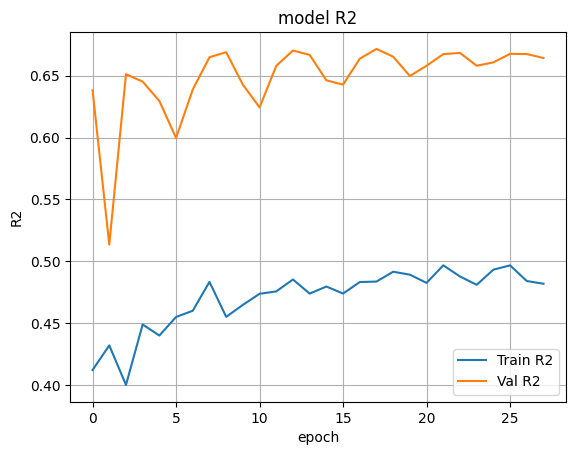

In [ ]:
from matplotlib import pyplot as plt
plt.plot(housing_model_values.history['r2_score'])
plt.plot(housing_model_values.history['val_r2_score'])
plt.legend(['Train R2', 'Val R2'])
plt.title('model R2')
plt.ylabel('R2')
plt.xlabel('epoch')
plt.grid(True)